# SCIENTIFIC ABSTRACTS

In [1]:
import spacy

# Load the language model
nlp = spacy.load("en_core_web_sm")

In [2]:
#Import libraries and combine the abstracts

import pandas as pd
from spacy.lang.en import English

# Load spaCy English model
nlp = English()

# Assuming arxiv_data.csv is in your working directory
df = pd.read_csv("arxiv_data.csv")

# Get the first 20 abstracts and combine them into one string
first_20_abstracts = " ".join(df["summaries"].iloc[:150])


In [3]:
#Tokenization

# Create a spaCy document from the combined abstracts
doc = nlp(first_20_abstracts)

# Get the tokens as a list
sci_tokens = [token.text.lower() for token in doc if not token.is_stop]



In [4]:
sci_lemmas = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha and not token.like_num]

In [5]:
#Calculating TTR

# Calculate the number of unique tokens (types)
unique_tokens = len(set(sci_tokens))

# Calculate TTR (ratio of unique tokens to total tokens)
ttr = unique_tokens / len(sci_tokens)

print("Scientific Abstracts")
print("Type-Token Ratio (TTR):", ttr)


Scientific Abstracts
Type-Token Ratio (TTR): 0.1492271105826397


In [6]:
# Count the PoS frequency and sort them 

import spacy
from collections import Counter
import pandas as pd

# Step 1: Make sure spaCy and the language model are installed
# pip install spacy
# python -m spacy download en_core_web_sm

# Step 2: Load the English language model
nlp = spacy.load("en_core_web_sm")

# Step 3: Process the document text with spaCy
doc = nlp(first_20_abstracts)

# Step 4: Count the parts of speech
pos_counts = Counter(token.pos_ for token in doc)

# Step 5: Create a DataFrame for nicer display and sort by frequency
pos_df_sorted = pd.DataFrame(pos_counts.items(), columns=[    "Part of Speech", "Frequency"]).sort_values(by="Frequency", ascending=False)

# Display the table
print(pos_df_sorted)

   Part of Speech  Frequency
0            NOUN       8691
8             ADJ       3913
11          PUNCT       3825
6            VERB       3426
3             ADP       3312
4             DET       2637
7           SPACE       2407
14          PROPN       1083
9            PRON       1076
5             ADV       1068
1             AUX        903
10          CCONJ        843
13           PART        595
12          SCONJ        290
2             NUM        245
15              X         48
16            SYM         18


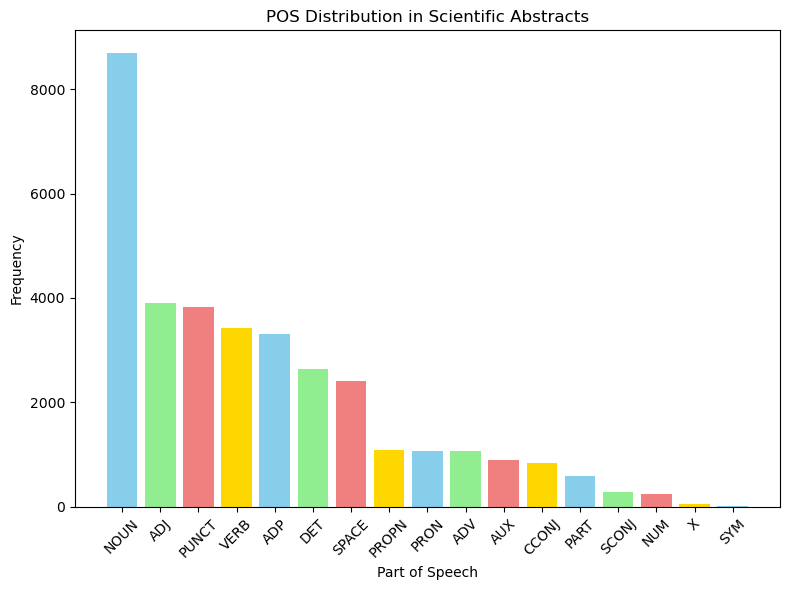

In [7]:
#Visualization

import matplotlib.pyplot as plt

# Get frequencies from DataFrame
pos = pos_df_sorted['Part of Speech']
frequency = pos_df_sorted['Frequency']

# Create a bar chart
plt.figure(figsize=(8, 6))  # Adjust figure size as desired
plt.bar(pos, frequency, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
plt.xlabel('Part of Speech')
plt.ylabel('Frequency')
plt.title('POS Distribution in Scientific Abstracts')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


In [8]:
# Count only the frequency of nouns, adjectives, verbs, and adverbs
pos_counts = {"NOUN": 0, "ADJ": 0, "VERB": 0, "ADV": 0}
for token in doc:
    if token.pos_ in pos_counts:
        pos_counts[token.pos_] += 1

# Convert the counts to a DataFrame for better visualization and sorting
pos_df_filtered = pd.DataFrame(list(pos_counts.items()), columns=['Part of Speech', 'Frequency'])

# Sort the DataFrame by Frequency in descending order
pos_df_filtered.sort_values(by='Frequency', ascending=False, inplace=True)

# Reset the index of the DataFrame for a clean table
pos_df_filtered.reset_index(drop=True, inplace=True)

# Display the table
print("Scientific Abstracts")
print(pos_df_filtered)

Scientific Abstracts
  Part of Speech  Frequency
0           NOUN       8691
1            ADJ       3913
2           VERB       3426
3            ADV       1068


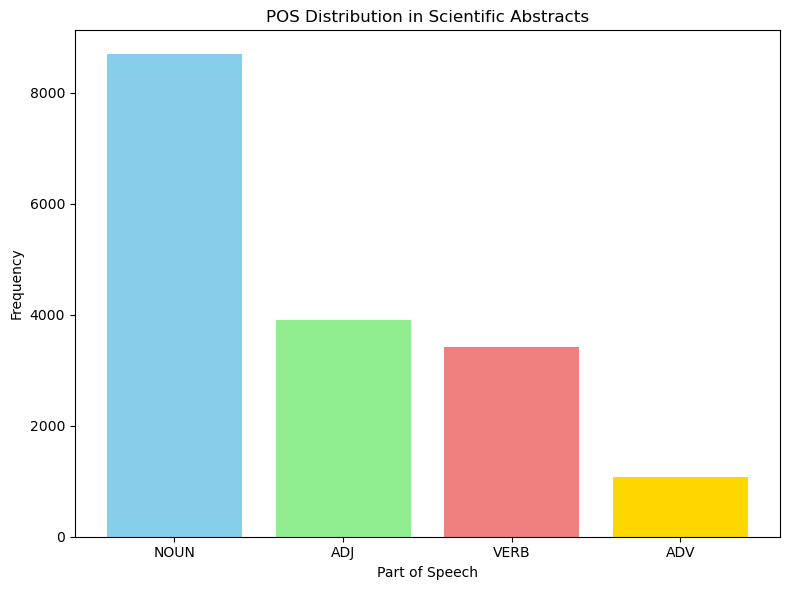

In [10]:
import matplotlib.pyplot as plt

# Get frequencies from DataFrame
pos = pos_df_filtered['Part of Speech']
frequency = pos_df_filtered['Frequency']

# Create a bar chart
plt.figure(figsize=(8, 6))  # Adjust figure size as desired
plt.bar(pos, frequency, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
plt.xlabel('Part of Speech')
plt.ylabel('Frequency')
plt.title('POS Distribution in Scientific Abstracts')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()
